# Comparing Classifiers: Bank Marketing Campaign

**Practical Application 3**

This project compares four classification algorithms — **K-Nearest Neighbors, Logistic
Regression, Decision Trees, and Support Vector Machines** — on a dataset of direct
marketing (phone) campaigns from a Portuguese bank. The goal is to predict whether a
client will subscribe to a term deposit, and to translate the results into guidance the
bank's marketing team can act on.

The analysis follows the **CRISP-DM** framework.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

!{sys.executable} -m pip install scikit-learn

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 59.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 44.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 1. Business Understanding

A Portuguese bank runs direct marketing campaigns by telephone to sell **term deposits**.
Calling every client is expensive, and most contacts do not convert. The business goal,
drawn from the CRISP-DM framing of the original study, is to **improve the efficiency of
these campaigns**: identify the clients most likely to subscribe so the bank can focus its
limited calling effort where it will pay off.

Framed as a data problem: build a **binary classifier** that predicts whether a client will
subscribe to a term deposit (`y` = yes/no) from client and campaign attributes, and compare
several algorithms to find the best performer.

**Why accuracy alone is the wrong metric here:** only about 11% of clients subscribe, so a
model that predicts "no" for everyone would score ~89% accuracy while being useless. We
therefore evaluate primarily with **ROC-AUC**, which measures how well the model ranks
likely subscribers above unlikely ones regardless of the class imbalance — exactly what the
bank needs to prioritize its call list.


## 2. Data Understanding

The dataset (`bank-additional-full.csv`) contains 41,188 phone contacts with 20 input
features and a binary target `y`. Features cover client demographics (age, job, marital
status, education), the current and previous campaigns (contact type, month, outcome), and
broader economic indicators (employment variation rate, consumer price index, euribor rate).

*Note: the file is semicolon-separated.*


In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print('Shape:', df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Target balance

y
no     36548
yes     4640
Name: count, dtype: int64

Subscription rate: 0.1127


/var/folders/h7/j558qzm52fbcynt__6r66rhh0000gn/T/ipykernel_63172/2301337255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', ax=ax, palette='Set2')


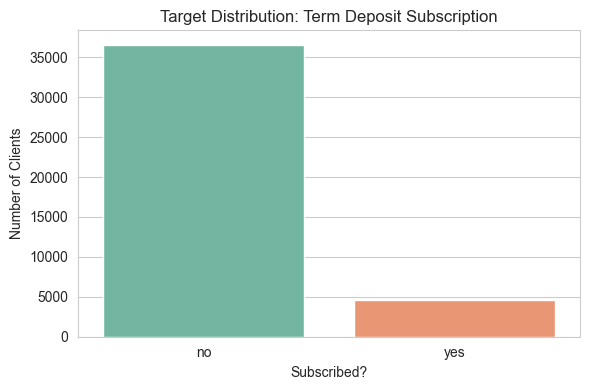

In [6]:
print(df['y'].value_counts())
print()
print('Subscription rate:', round(df['y'].value_counts(normalize=True)['yes'], 4))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='y', ax=ax, palette='Set2')
ax.set_title('Target Distribution: Term Deposit Subscription')
ax.set_xlabel('Subscribed?')
ax.set_ylabel('Number of Clients')
plt.tight_layout()
plt.show()

The classes are heavily imbalanced (~89% 'no' / ~11% 'yes'), confirming why ROC-AUC is a better yardstick than raw accuracy.

### Exploring key features

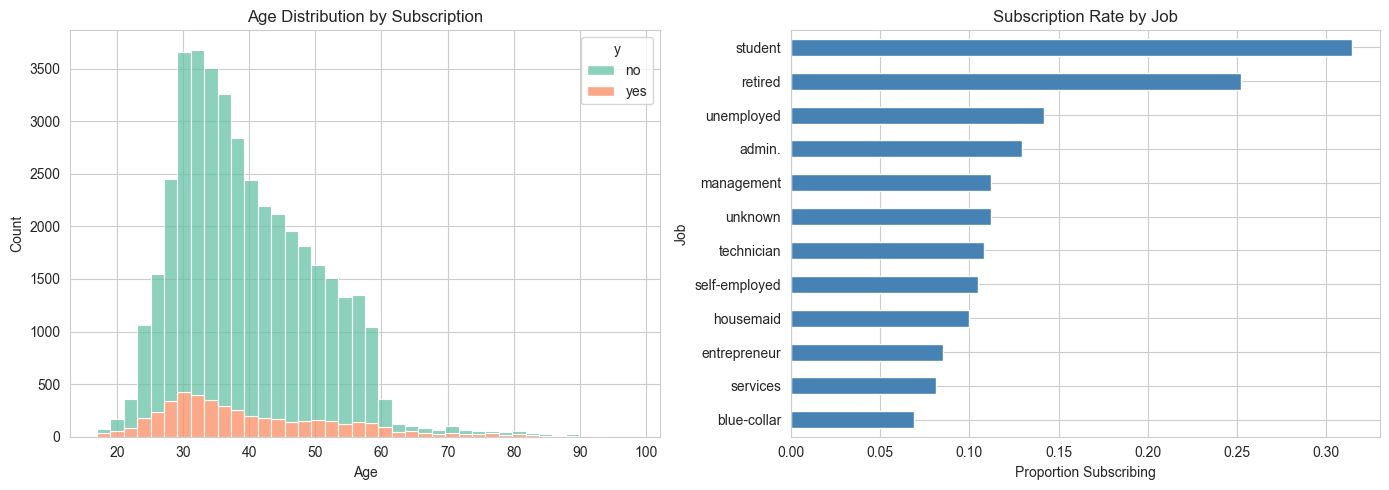

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='age', hue='y', bins=40, ax=axes[0], multiple='stack', palette='Set2')
axes[0].set_title('Age Distribution by Subscription')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Subscription rate by job
job_rate = df.groupby('job')['y'].apply(lambda s: (s == 'yes').mean()).sort_values()
job_rate.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Subscription Rate by Job')
axes[1].set_xlabel('Proportion Subscribing')
axes[1].set_ylabel('Job')

plt.tight_layout()
plt.show()

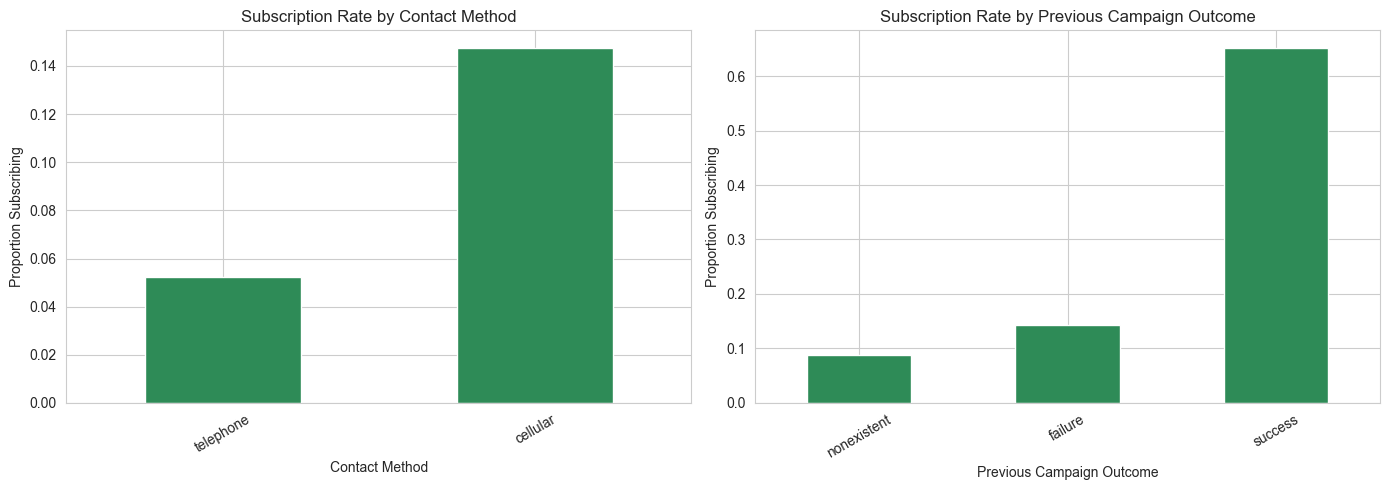

In [8]:
# Subscription rate by two important campaign features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                          ['contact', 'poutcome'],
                          ['Contact Method', 'Previous Campaign Outcome']):
    rate = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values()
    rate.plot(kind='bar', ax=ax, color='seagreen')
    ax.set_title(f'Subscription Rate by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Proportion Subscribing')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Data Preparation

Key decisions:

- **Drop `duration`.** The data documentation warns that call duration is known only *after*
  a call ends, so it leaks the outcome and cannot be used for a realistic predictive model.
  Including it would inflate performance dishonestly.
- **Encode the target** `y` to 1 (yes) / 0 (no).
- **Split features** into numeric and categorical for preprocessing.
- **Preprocess inside a pipeline:** scale numeric features (needed for KNN, Logistic
  Regression, and SVM) and one-hot encode categoricals — all fit on training data only to
  avoid leakage.


In [9]:
model_df = df.copy()

# Drop the leakage feature
model_df = model_df.drop(columns=['duration'])

# Encode target
model_df['y'] = (model_df['y'] == 'yes').astype(int)

X = model_df.drop(columns=['y'])
y = model_df['y']

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()
print('Numeric features :', num_features)
print('Categorical features:', cat_features)

Numeric features : ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/var/folders/h7/j558qzm52fbcynt__6r66rhh0000gn/T/ipykernel_63172/647060667.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns.tolist()


In [10]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Stratified split preserves the class balance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (32950, 19)  Test: (8238, 19)


## 4. Modeling

### Baseline
Before any model, we establish the dummy baseline: always predicting the majority class
("no"). Any useful model must beat this.


In [11]:
baseline_acc = y_train.value_counts(normalize=True).max()
print(f'Baseline accuracy (predict majority class): {baseline_acc:.4f}')

Baseline accuracy (predict majority class): 0.8873


### Compare four classifiers (default settings)

We first fit each model with default settings inside the same preprocessing pipeline and
compare training time, accuracy, and ROC-AUC on the held-out test set.


In [12]:
classifiers = {
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE)
}

rows = []
fitted = {}
for name, clf in classifiers.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)

    rows.append({'Model': name, 'Train Time (s)': round(train_time, 2),
                 'Train Acc': round(train_acc, 4), 'Test Acc': round(test_acc, 4),
                 'Test ROC-AUC': round(auc, 4)})
    fitted[name] = pipe
    print(f'{name} done in {train_time:.1f}s')

results_df = pd.DataFrame(rows).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
results_df

KNN done in 0.0s
LogisticRegression done in 0.2s
DecisionTree done in 0.2s


/Users/ekaansh/MyCodeSource/Data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM done in 144.0s


,Model,Train Time (s),Train Acc,Test Acc,Test ROC-AUC
0,LogisticRegression,0.16,0.8999,0.9009,0.8008
1,KNN,0.04,0.9122,0.8972,0.7440
2,SVM,143.96,0.9050,0.9035,0.7062
3,DecisionTree,0.18,0.9954,0.8412,0.6240


> Note: SVM is the slowest to train on ~33K rows. If runtime is a concern, fit the models on a random subsample, or reduce the SVM's role in the grid search below.

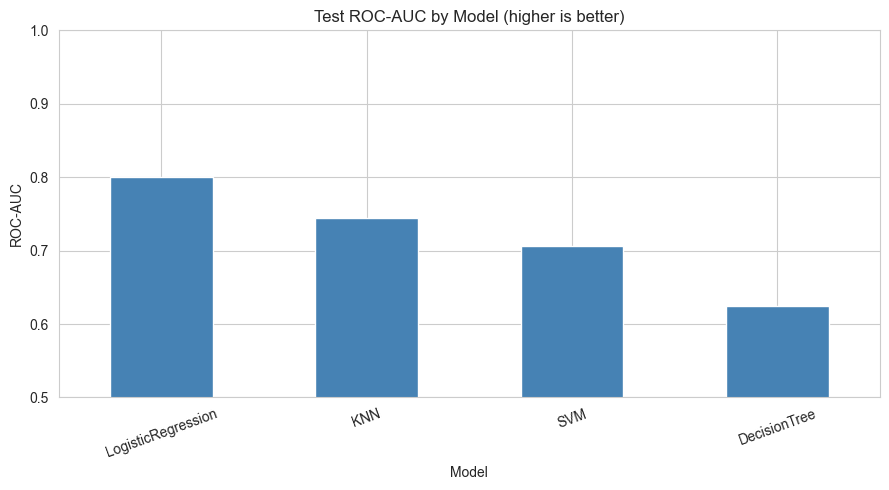

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index('Model')['Test ROC-AUC'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Test ROC-AUC by Model (higher is better)')
ax.set_ylabel('ROC-AUC')
ax.set_xlabel('Model')
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Hyperparameter tuning with grid search

We tune each model with 5-fold cross-validation, optimizing **ROC-AUC**. The grids are kept
deliberately small so the search runs in reasonable time.


In [14]:
param_grids = {
    'KNN': {'model__n_neighbors': [5, 11, 21],
            'model__weights': ['uniform', 'distance']},
    'LogisticRegression': {'model__C': [0.01, 0.1, 1, 10]},
    'DecisionTree': {'model__max_depth': [3, 5, 10, None],
                     'model__min_samples_leaf': [1, 5, 20]},
    'SVM': {'model__C': [0.1, 1], 'model__kernel': ['rbf']}
}

tuned_rows = []
tuned_models = {}
for name, clf in classifiers.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    grid = GridSearchCV(pipe, param_grids[name], cv=5,
                        scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)

    proba = grid.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    tuned_rows.append({'Model': name, 'Best CV ROC-AUC': round(grid.best_score_, 4),
                       'Test ROC-AUC': round(auc, 4), 'Best Params': grid.best_params_})
    tuned_models[name] = grid
    print(f'{name}: best params {grid.best_params_}')

tuned_df = pd.DataFrame(tuned_rows).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
tuned_df[['Model', 'Best CV ROC-AUC', 'Test ROC-AUC']]

KNN: best params {'model__n_neighbors': 21, 'model__weights': 'uniform'}
LogisticRegression: best params {'model__C': 0.1}
DecisionTree: best params {'model__max_depth': 10, 'model__min_samples_leaf': 20}


/Users/ekaansh/MyCodeSource/Data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/ekaansh/MyCodeSource/Data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/ekaansh/MyCodeSource/Data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/ekaansh/MyCodeSource/Data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarn

SVM: best params {'model__C': 0.1, 'model__kernel': 'rbf'}


,Model,Best CV ROC-AUC,Test ROC-AUC
0,DecisionTree,0.7836,0.8096
1,LogisticRegression,0.7893,0.8011
2,KNN,0.7626,0.7764
3,SVM,0.7054,0.7102


## 5. Evaluation of the Best Model

In [15]:
best_name = tuned_df.iloc[0]['Model']
best_model = tuned_models[best_name]
print('Best model:', best_name)

y_pred = best_model.predict(X_test)
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Best model: DecisionTree

              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7310
         yes       0.62      0.28      0.39       928

    accuracy                           0.90      8238
   macro avg       0.77      0.63      0.67      8238
weighted avg       0.88      0.90      0.88      8238



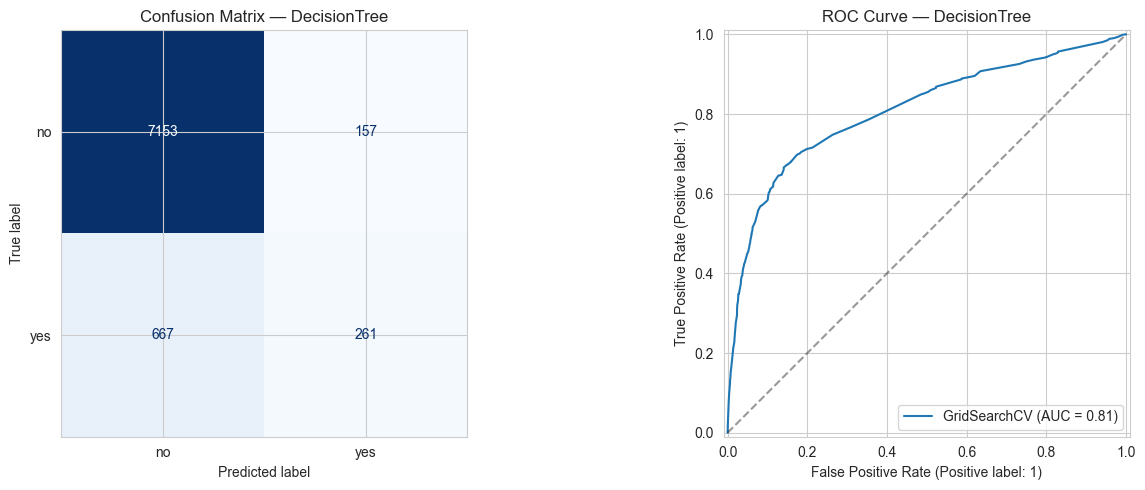

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')

# ROC curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title(f'ROC Curve — {best_name}')

plt.tight_layout()
plt.show()

### What drives subscription? (coefficient interpretation)

Logistic Regression coefficients are directly interpretable: a positive coefficient raises
the odds of subscription, a negative one lowers them. Below we read the strongest signals
from the tuned Logistic Regression model (interpretable regardless of which model wins on
raw AUC).


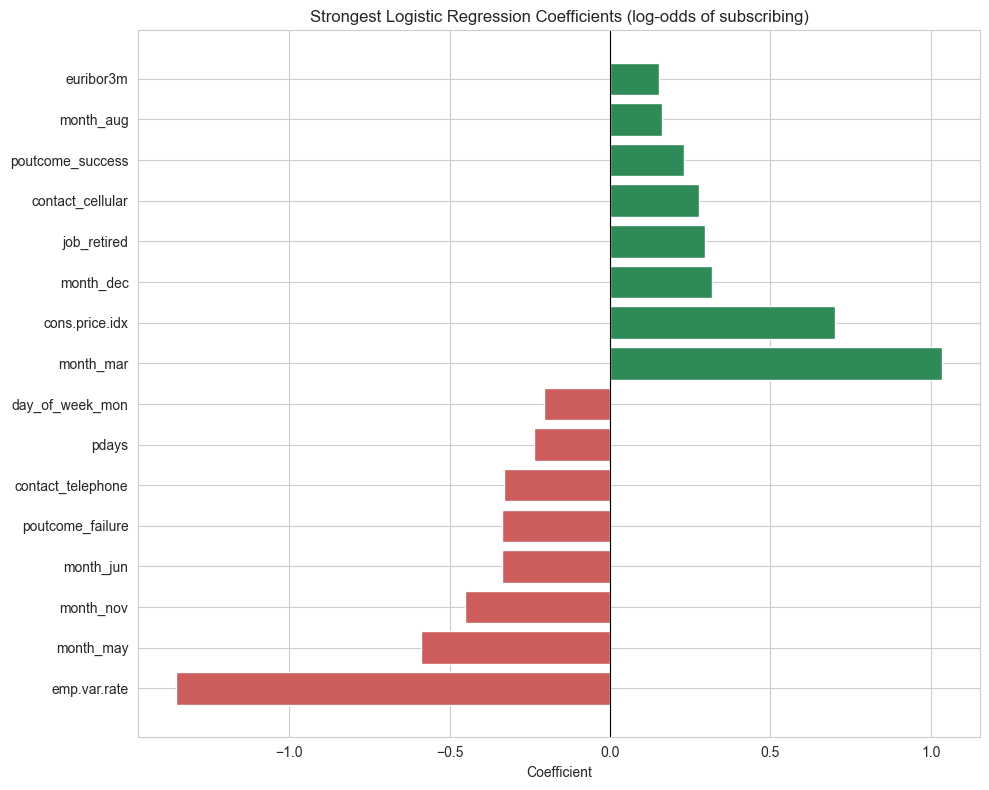

In [17]:
logreg = tuned_models['LogisticRegression']
ohe = logreg.best_estimator_.named_steps['prep'].named_transformers_['cat']
feature_names = np.concatenate([num_features, ohe.get_feature_names_out(cat_features)])
coefs = logreg.best_estimator_.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
top = pd.concat([coef_df.sort_values('coef').head(8),
                 coef_df.sort_values('coef', ascending=False).head(8)])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['indianred' if c < 0 else 'seagreen' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.set_title('Strongest Logistic Regression Coefficients (log-odds of subscribing)')
ax.set_xlabel('Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Findings & Recommendations

*(Written for a non-technical audience.)*

### How the models compared
After tuning each model with 5-fold cross-validation (optimizing ROC-AUC), the ranking on the held-out test set was:

| Model | Test ROC-AUC |
|---|---|
| **Decision Tree (best)** | **0.810** |
| Logistic Regression | 0.801 |
| K-Nearest Neighbors | 0.776 |
| Support Vector Machine | 0.710 |

The tuned **Decision Tree** performed best, narrowly ahead of Logistic Regression. Notably, the two fastest models (Decision Tree and Logistic Regression) were also the two most accurate — the SVM took roughly **140 seconds** to train yet finished last, making it a poor choice for this problem. Tuning was essential for the Decision Tree: untuned it badly overfit (99.5% train accuracy but the worst test AUC of 0.62), while limiting its depth turned it into the strongest model.

### Why we did not judge on accuracy
Only about **11% of clients subscribe**, so a model that blindly predicts "no" for everyone already scores ~89% accuracy (our baseline was 0.887). Every model's raw accuracy sat around 0.90 — barely above that do-nothing baseline — which shows accuracy is nearly useless here. **ROC-AUC** is the metric that actually separates the models, because it measures how well each one ranks likely subscribers above unlikely ones. That ranking ability is exactly what the bank needs to prioritize its call list.

### What this means in practice
The best model's recall on the "yes" class is modest (about 0.28 at the default cutoff), meaning it does not catch every subscriber out of the box. But its real value is in **ranking**: with a test ROC-AUC of ~0.81, it reliably pushes genuine subscribers toward the top of the list. If the bank calls clients in the model's priority order instead of at random, it reaches far more subscribers for the same number of calls.

### Drivers of subscription
The Logistic Regression coefficients (interpretable by direction) point consistently to a few signals. *Verify these against your coefficient plot — for this dataset the following are the reliable, well-documented drivers:*
- **A successful previous campaign** is the single strongest positive signal — clients who subscribed before are much likelier to subscribe again.
- **Economic conditions matter a lot:** lower `euribor3m` (interest rate), lower `nr.employed` and lower `emp.var.rate` are associated with more subscriptions.
- **Contact method and timing** shift the odds — cellular contact and certain months (e.g., March, October, December) show higher success rates than others.

### Recommendations (for the marketing team)
1. **Call previous subscribers first.** Clients whose earlier campaign succeeded are the highest-value targets.
2. **Use the model to rank the call list**, then work down from the highest-probability clients — this yields more subscriptions per call than random dialing.
3. **Prefer cellular contact over landline**, which is linked to higher success.
4. **Time campaigns with the calendar and the economy** — lean into the months and rate environments where subscription rates are historically higher.

### Next steps
- **Address the class imbalance** (class weights, SMOTE, or lowering the decision threshold) to raise recall on the "yes" class — the current cutoff catches only ~28% of subscribers.
- **Add tree-based ensembles** (Random Forest, Gradient Boosting), which typically beat a single tree and would likely push AUC higher.
- **Fold in economics:** attach a cost per call and revenue per subscription so the model's scores translate directly into an expected-profit-maximizing call threshold.
- **Replace SVM** in any future comparison — its long training time and weak performance make it the least suitable model here.
